In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report)

import tensorflow as tf

In [2]:
df = pd.read_csv('f1_processed_dataset.csv')
df

,raceId,driverId,constructorId,grid,positionOrder,top3,year,round,circuitId,driver_nationality,driver_age,constructor_nationality,quali_position
0,18,1,1,1,1,1,2008,1,1,British,23.186858,British,1.0
1,18,2,2,5,2,1,2008,1,1,German,30.850103,German,5.0
2,18,3,3,7,3,1,2008,1,1,German,22.718686,British,7.0
3,18,4,4,11,4,0,2008,1,1,Spanish,26.631075,French,12.0
4,18,5,1,3,5,0,2008,1,1,Finnish,26.406571,British,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,1144,825,210,14,16,0,2024,24,24,Danish,32.175222,American,15.0
26755,1144,859,215,12,17,0,2024,24,24,New Zealander,22.822724,Italian,12.0
26756,1144,822,15,9,18,0,2024,24,24,Finnish,35.279945,Swiss,9.0
26757,1144,861,3,20,19,0,2024,24,24,Argentinian,21.535934,British,19.0


In [4]:
print(df.head())


   raceId  driverId  constructorId  grid  positionOrder  top3  year  round  \
0      18         1              1     1              1     1  2008      1   
1      18         2              2     5              2     1  2008      1   
2      18         3              3     7              3     1  2008      1   
3      18         4              4    11              4     0  2008      1   
4      18         5              1     3              5     0  2008      1   

   circuitId driver_nationality  driver_age constructor_nationality  \
0          1            British   23.186858                 British   
1          1             German   30.850103                  German   
2          1             German   22.718686                 British   
3          1            Spanish   26.631075                  French   
4          1            Finnish   26.406571                 British   

   quali_position  
0             1.0  
1             5.0  
2             7.0  
3            12.0  
4   

In [5]:
X = df.drop(columns=['top3', 'positionOrder', 'driverId', 'constructorId', 'raceId'])
y = df['top3']

In [6]:
df['grid_vs_quali'] = df['grid'] - df['quali_position']
df['log_grid'] = np.log1p(df['grid'])
df['quali_efficiency'] = df['quali_position'] / df['grid']
df['grid_advantage'] = df['grid'] <= 3

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

#80 % - trening

In [9]:
X_val, X_test, y_val, y_test = train_test_split(
X_temp,
y_temp,
test_size=0.50,
random_state=42,
stratify=y_temp
)

#10 % val + 10 % test

In [10]:
#tekstowe kolumny
categorical_cols = [
'driver_nationality',
'constructor_nationality'
]
#kolumny liczbowe
numeric_cols = [
'grid',
'year',
'round',
'circuitId',
'driver_age',
'quali_position'
]



In [11]:
#Preprocessing - zmiana tekstu na liczby (onehot encoding) + skalowanie

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [12]:
#Transformacja danych

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [13]:
#Model

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_processed.shape[1],)),

    tf.keras.layers.Dense(128, activation='relu',
                           kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [14]:
#compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

In [15]:
#early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True)

In [16]:
#waga
class_weight = {0: 1, 1: 1.5}

In [17]:
#training
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1)

Epoch 1/100
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8742 - auc: 0.8344 - loss: 0.4155 - val_accuracy: 0.8744 - val_auc: 0.8600 - val_loss: 0.3179
Epoch 2/100
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8810 - auc: 0.8625 - loss: 0.3698 - val_accuracy: 0.8812 - val_auc: 0.8682 - val_loss: 0.3002
Epoch 3/100
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8820 - auc: 0.8718 - loss: 0.3568 - val_accuracy: 0.8845 - val_auc: 0.8744 - val_loss: 0.2857
Epoch 4/100
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8837 - auc: 0.8779 - loss: 0.3484 - val_accuracy: 0.8965 - val_auc: 0.8802 - val_loss: 0.2729
Epoch 5/100
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8862 - auc: 0.8849 - loss: 0.3389 - val_accuracy: 0.8883 - val_auc: 0.8868 - val_loss: 0.2803
Epoch 6/100
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8865 - auc: 0.8867 - loss: 0.3360 - val_accuracy: 0.8864 - val_auc: 0.8886 - val_loss: 0.2725
Epoch 7/100
335/335 ━━━━━━━━━━━━━━

In [126]:
#threshold -> 0.4
y_pred_prob = model.predict(X_test_processed)
y_pred = (y_pred_prob > 0.4).astype(int)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [127]:
#Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-score:', f1)
print('ROC-AUC:', roc_auc)
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8800448430493274
Precision: 0.5239294710327456
Recall: 0.611764705882353
F1-score: 0.5644504748982361
ROC-AUC: 0.8926609085414989

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2336
           1       0.52      0.61      0.56       340

    accuracy                           0.88      2676
   macro avg       0.73      0.77      0.75      2676
weighted avg       0.89      0.88      0.88      2676


Confusion Matrix:

[[2147  189]
 [ 132  208]]


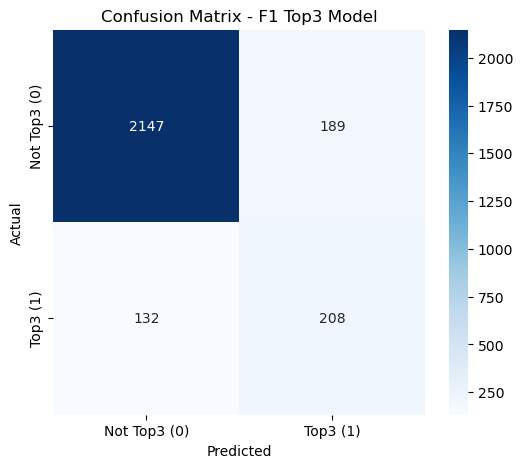

In [128]:
#confusion mtx

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Top3 (0)', 'Top3 (1)'],
            yticklabels=['Not Top3 (0)', 'Top3 (1)'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - F1 Top3 Model')
plt.show()

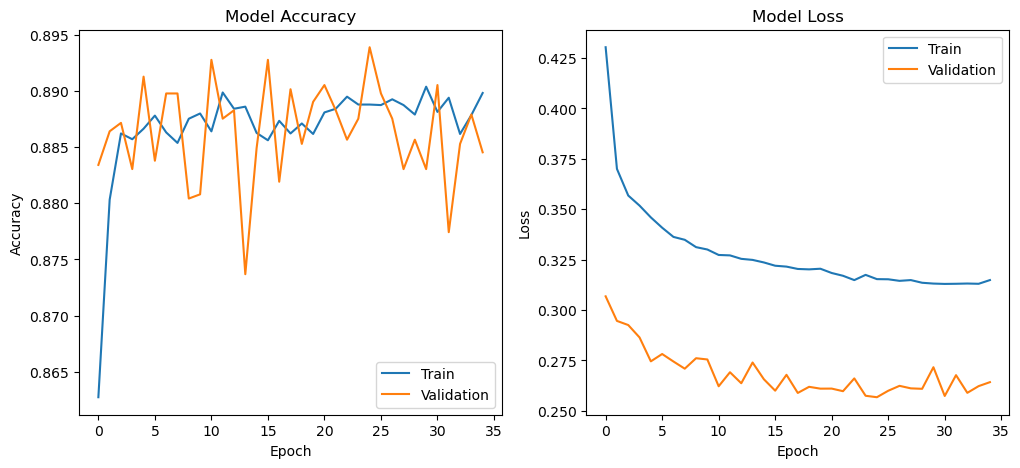

In [129]:
#Accuracy + loss

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()